In [ ]:
import win32com.client as win32
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

from economic_analysis import annual_utility_cost
from economic_analysis import total_energy

In [ ]:
BASE_DIR = Path.cwd()       
MODEL_PATH = BASE_DIR.parent / "aspen-model" / "ethyl-acetate-optimization - heat integration.bkp"

aspen = win32.Dispatch("Apwn.Document")
aspen.InitFromArchive2(str(MODEL_PATH))

In [4]:
aspen.Tree.FindNode(
    r"\Data\Blocks\RADFRAC1\Input\BASIS_RR"
).Value = 2.0

aspen.Tree.FindNode(
    r"\Data\Streams\ETH-ACE\Input\FLOW\MIXED\ETHANOL"
).Value = 50

aspen.Tree.FindNode(
    r"\Data\Streams\ETH-ACE\Input\FLOW\MIXED\ACETI-01"
).Value = 50

aspen.Engine.Run2()

In [5]:
pressure_values = np.arange(1.0, 5.5, 0.5)

results = []

In [6]:
for pressure in pressure_values:

    print(f"Running {pressure:.1f} bar")


    aspen.Tree.FindNode(
        r"\Data\Blocks\RADFRAC1\Input\PRES1"
    ).Value = pressure

    aspen.Engine.Run2()


    purity = aspen.Tree.FindNode(
        r"\Data\Streams\LIQ-DIST\Output\MOLEFRAC\MIXED\ETHYL-01"
    ).Value

    condenser = aspen.Tree.FindNode(
        r"\Data\Blocks\RADFRAC1\Output\COND_DUTY"
    ).Value

    reboiler = aspen.Tree.FindNode(
        r"\Data\Blocks\RADFRAC1\Output\REB_DUTY"
    ).Value
    
    cost = annual_utility_cost(        
    condenser,
    reboiler)

    energy = total_energy(
    condenser,
    reboiler)

    results.append([
    pressure,
    purity,
    condenser,
    reboiler,
    energy,
    cost])

Running 1.0 bar
Running 1.5 bar
Running 2.0 bar
Running 2.5 bar
Running 3.0 bar
Running 3.5 bar
Running 4.0 bar
Running 4.5 bar
Running 5.0 bar


In [ ]:
df = pd.DataFrame(
    results,columns=[
        "Pressure (bar)",
        "Purity",
        "Condenser Duty",
        "Reboiler Duty",
        "Total Energy",
        "Annual Utility Cost"
    ]
)

DATA_DIR = BASE_DIR.parent / "data"
DATA_DIR.mkdir(exist_ok=True)

df.to_csv(DATA_DIR / "pressure_results.csv", index=False)

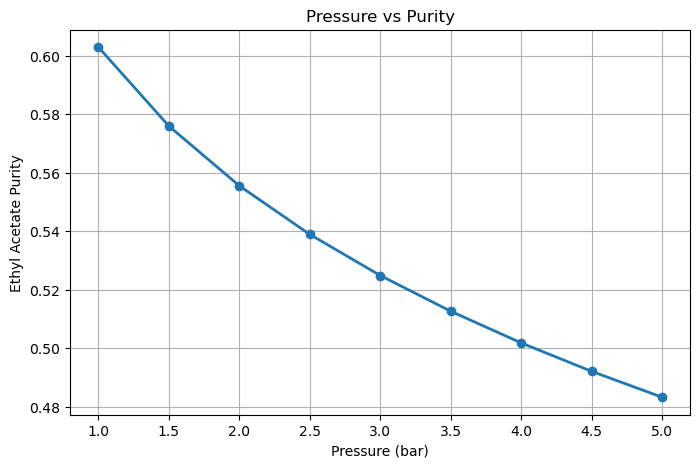

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    df["Pressure (bar)"],
    df["Purity"],
    marker="o",
    linewidth=2
)

plt.xlabel("Pressure (bar)")
plt.ylabel("Ethyl Acetate Purity")
plt.title("Pressure vs Purity")

plt.grid(True)


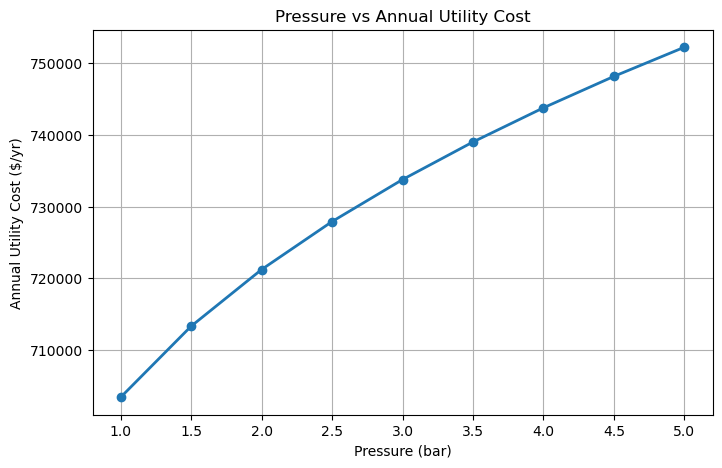

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    df["Pressure (bar)"],
    df["Annual Utility Cost"],
    marker="o",
    linewidth=2
)

plt.xlabel("Pressure (bar)")
plt.ylabel("Annual Utility Cost ($/yr)")
plt.title("Pressure vs Annual Utility Cost")

plt.grid(True)



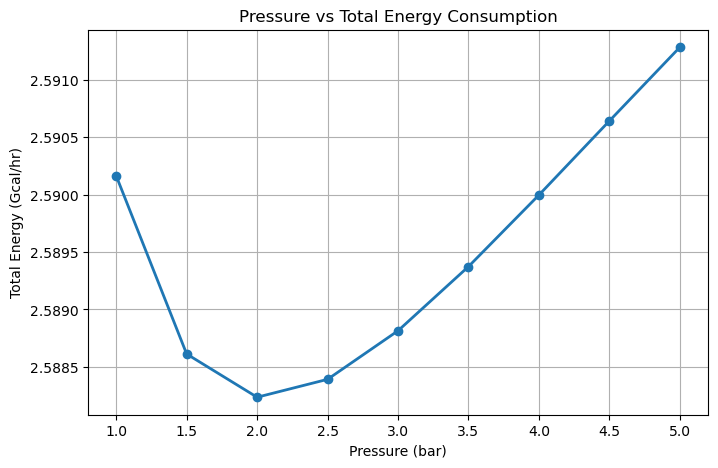

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    df["Pressure (bar)"],
    df["Total Energy"],
    marker="o",
    linewidth=2
)

plt.xlabel("Pressure (bar)")
plt.ylabel("Total Energy (Gcal/hr)")
plt.title("Pressure vs Total Energy Consumption")

plt.grid(True)

plt.show()

In [11]:
aspen.Close()
del aspen